<a href="https://colab.research.google.com/github/95ju/transaction_monitoring_analysis/blob/main/Transaction_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup

In [5]:

import pandas as pd
df=pd.read_csv ('transaction_data.csv', on_bad_lines='skip')
df['Revenue']=df['NumberOfItemsPurchased']*df['CostPerItem']

#Project Objective

In [ ]:
This project analyses transaction-level data to identify revenue trends, refund activity, anomalies, and business insights using Python and pandas.

In [ ]:


import pandas as pd
df=pd.read_csv ('transaction_data.csv')
df.head ()

,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country
0,278166,6355745,Sat Feb 02 12:50:00 IST 2019,465549,FAMILY ALBUM WHITE PICTURE FRAME,6,11.73,United Kingdom
1,337701,6283376,Wed Dec 26 09:06:00 IST 2018,482370,LONDON BUS COFFEE MUG,3,3.52,United Kingdom
2,267099,6385599,Fri Feb 15 09:45:00 IST 2019,490728,SET 12 COLOUR PENCILS DOLLY GIRL,72,0.90,France
3,380478,6044973,Fri Jun 22 07:14:00 IST 2018,459186,UNION JACK FLAG LUGGAGE TAG,3,1.73,United Kingdom
4,-1,6143225,Mon Sep 10 11:58:00 IST 2018,1733592,WASHROOM METAL SIGN,3,3.40,United Kingdom


#data exploration


This section explores the structure, size, colum types, and distribution of the transaction dataset.

In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1083818 entries, 0 to 1083817
Data columns (total 8 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   UserId                  1083818 non-null  int64  
 1   TransactionId           1083818 non-null  int64  
 2   TransactionTime         1083818 non-null  object 
 3   ItemCode                1083818 non-null  int64  
 4   ItemDescription         1080910 non-null  object 
 5   NumberOfItemsPurchased  1083818 non-null  int64  
 6   CostPerItem             1083818 non-null  float64
 7   Country                 1083818 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 66.2+ MB


In [ ]:
df['Country'].value_counts()

,count
Country,
United Kingdom,990956
Germany,18990
France,17114
EIRE,16392
Spain,5066
Netherlands,4742
Belgium,4138
Switzerland,4004
Portugal,3038


In [ ]:
df['ItemDescription'].value_counts().head(10)

,count
ItemDescription,
WHITE HANGING HEART T-LIGHT HOLDER,4738
REGENCY CAKESTAND 3 TIER,4400
JUMBO BAG RED RETROSPOT,4318
PARTY BUNTING,3454
LUNCH BAG RED RETROSPOT,3276
ASSORTED COLOUR BIRD ORNAMENT,3002
SET OF 3 CAKE TINS PANTRY DESIGN,2946
PACK OF 72 RETROSPOT CAKE CASES,2770
LUNCH BAG BLACK SKULL.,2700


In [ ]:
import pandas as pd
df=pd.read_csv('transaction_data.csv')
df.head()

,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country
0,278166,6355745,Sat Feb 02 12:50:00 IST 2019,465549,FAMILY ALBUM WHITE PICTURE FRAME,6,11.73,United Kingdom
1,337701,6283376,Wed Dec 26 09:06:00 IST 2018,482370,LONDON BUS COFFEE MUG,3,3.52,United Kingdom
2,267099,6385599,Fri Feb 15 09:45:00 IST 2019,490728,SET 12 COLOUR PENCILS DOLLY GIRL,72,0.90,France
3,380478,6044973,Fri Jun 22 07:14:00 IST 2018,459186,UNION JACK FLAG LUGGAGE TAG,3,1.73,United Kingdom
4,-1,6143225,Mon Sep 10 11:58:00 IST 2018,1733592,WASHROOM METAL SIGN,3,3.40,United Kingdom


In [ ]:
df['Revenue']=df['NumberOfItemsPurchased']*df['CostPerItem']

In [ ]:
df[['ItemDescription','Revenue']].head()

,ItemDescription,Revenue
0,FAMILY ALBUM WHITE PICTURE FRAME,70.38
1,LONDON BUS COFFEE MUG,10.56
2,SET 12 COLOUR PENCILS DOLLY GIRL,64.80
3,UNION JACK FLAG LUGGAGE TAG,5.19
4,WASHROOM METAL SIGN,10.20


In [ ]:
df.groupby('ItemDescription')['Revenue'].sum().sort_values(ascending=False).head(10)

,Revenue
ItemDescription,
RETROSPOT LAMP,81448932.90
DOTCOM POSTAGE,1707732.60
REGENCY CAKESTAND 3 TIER,1364809.32
WHITE HANGING HEART T-LIGHT HOLDER,826236.24
PARTY BUNTING,814646.34
JUMBO BAG RED RETROSPOT,766949.46
RABBIT NIGHT LIGHT,554402.28
POSTAGE,548388.66
PAPER CHAIN KIT 50'S CHRISTMAS,528720.72


Step: find the products generating the MOST revenue

Top products by Revenue
I calculated revenue using:
Revenue=NumberOfItemsPurchased*CostPerItem
then i grouped the data by product description to identify which products generated the most revenue

key insigts:
Some products are sold very frequently
high selling pruducts may be important for inventory management
the company could prioritize these items for marketing and promotions



In [ ]:
import pandas as pd
df=pd.read_csv('transaction_data.csv')
df.head()

,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country
0,278166,6355745,Sat Feb 02 12:50:00 IST 2019,465549,FAMILY ALBUM WHITE PICTURE FRAME,6,11.73,United Kingdom
1,337701,6283376,Wed Dec 26 09:06:00 IST 2018,482370,LONDON BUS COFFEE MUG,3,3.52,United Kingdom
2,267099,6385599,Fri Feb 15 09:45:00 IST 2019,490728,SET 12 COLOUR PENCILS DOLLY GIRL,72,0.90,France
3,380478,6044973,Fri Jun 22 07:14:00 IST 2018,459186,UNION JACK FLAG LUGGAGE TAG,3,1.73,United Kingdom
4,-1,6143225,Mon Sep 10 11:58:00 IST 2018,1733592,WASHROOM METAL SIGN,3,3.40,United Kingdom


In [ ]:
df['Revenue']=df['NumberOfItemsPurchased']*df['CostPerItem']

In [ ]:
df.sort_values(by='Revenue', ascending=False).head(10)

,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country,Revenue
854978,288687,5900323,Mon Feb 12 06:37:00 IST 2018,465780,RETROSPOT LAMP,24,1696285.44,United Kingdom,40710850.56
320282,288687,5900323,Mon Feb 12 06:37:00 IST 2018,465780,RETROSPOT LAMP,24,1696285.44,United Kingdom,40710850.56
691746,345366,6396313,Wed Feb 20 05:15:00 IST 2019,500703,"PAPER CRAFT , LITTLE BIRDIE",242985,2.88,United Kingdom,699796.80
510647,345366,6396313,Wed Feb 20 05:15:00 IST 2019,500703,"PAPER CRAFT , LITTLE BIRDIE",242985,2.88,United Kingdom,699796.80
528376,259266,5955741,Sun Apr 01 06:01:00 IST 2018,486486,MEDIUM CERAMIC TOP STORAGE JAR,222645,1.44,United Kingdom,320608.80
1010231,259266,5955741,Sun Apr 01 06:01:00 IST 2018,486486,MEDIUM CERAMIC TOP STORAGE JAR,222645,1.44,United Kingdom,320608.80
124370,317058,6120884,Wed Aug 22 11:28:00 IST 2018,472542,PICNIC BASKET WICKER 60 PIECES,180,896.31,United Kingdom,161335.80
920858,317058,6120884,Wed Aug 22 11:28:00 IST 2018,472542,PICNIC BASKET WICKER 60 PIECES,180,896.31,United Kingdom,161335.80
969333,-1,5913952,Fri Feb 18 11:08:00 IST 2028,-1,AMAZON FEE,3,18687.04,United Kingdom,56061.12
940702,-1,5913952,Fri Feb 18 11:08:00 IST 2028,-1,AMAZON FEE,3,18687.04,United Kingdom,56061.12


In [ ]:
df.sort_values(by='Revenue',ascending=False)[['TransactionId','ItemDescription','Revenue','Country']]. head(10)

,TransactionId,ItemDescription,Revenue,Country
854978,5900323,RETROSPOT LAMP,40710850.56,United Kingdom
320282,5900323,RETROSPOT LAMP,40710850.56,United Kingdom
691746,6396313,"PAPER CRAFT , LITTLE BIRDIE",699796.80,United Kingdom
510647,6396313,"PAPER CRAFT , LITTLE BIRDIE",699796.80,United Kingdom
528376,5955741,MEDIUM CERAMIC TOP STORAGE JAR,320608.80,United Kingdom
1010231,5955741,MEDIUM CERAMIC TOP STORAGE JAR,320608.80,United Kingdom
124370,6120884,PICNIC BASKET WICKER 60 PIECES,161335.80,United Kingdom
920858,6120884,PICNIC BASKET WICKER 60 PIECES,161335.80,United Kingdom
969333,5913952,AMAZON FEE,56061.12,United Kingdom
940702,5913952,AMAZON FEE,56061.12,United Kingdom


Some transactions showed unusually high revenue values, which could indicate bulk purchases, data quality issues, or transaction requiring further investigation'threshold- based monitoring identified several unusual large transactions with exceptionally high quantities or item prices, suggesting potential anomalies or data quality issues requiring further investigation

In [ ]:
df[df['Revenue']>50000]

,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country,Revenue
124370,317058,6120884,Wed Aug 22 11:28:00 IST 2018,472542,PICNIC BASKET WICKER 60 PIECES,180,896.31,United Kingdom,161335.80
320282,288687,5900323,Mon Feb 12 06:37:00 IST 2018,465780,RETROSPOT LAMP,24,1696285.44,United Kingdom,40710850.56
510647,345366,6396313,Wed Feb 20 05:15:00 IST 2019,500703,"PAPER CRAFT , LITTLE BIRDIE",242985,2.88,United Kingdom,699796.80
528376,259266,5955741,Sun Apr 01 06:01:00 IST 2018,486486,MEDIUM CERAMIC TOP STORAGE JAR,222645,1.44,United Kingdom,320608.80
691746,345366,6396313,Wed Feb 20 05:15:00 IST 2019,500703,"PAPER CRAFT , LITTLE BIRDIE",242985,2.88,United Kingdom,699796.80
854978,288687,5900323,Mon Feb 12 06:37:00 IST 2018,465780,RETROSPOT LAMP,24,1696285.44,United Kingdom,40710850.56
920858,317058,6120884,Wed Aug 22 11:28:00 IST 2018,472542,PICNIC BASKET WICKER 60 PIECES,180,896.31,United Kingdom,161335.80
940702,-1,5913952,Fri Feb 18 11:08:00 IST 2028,-1,AMAZON FEE,3,18687.04,United Kingdom,56061.12
969333,-1,5913952,Fri Feb 18 11:08:00 IST 2028,-1,AMAZON FEE,3,18687.04,United Kingdom,56061.12
1010231,259266,5955741,Sun Apr 01 06:01:00 IST 2018,486486,MEDIUM CERAMIC TOP STORAGE JAR,222645,1.44,United Kingdom,320608.80


In [ ]:
df['Revenue']=df['NumberOfItemsPurchased']*df['CostPerItem']

In [ ]:
df.sort_values(by='Revenue', ascending=False).head(10)

,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country,Revenue
854978,288687,5900323,Mon Feb 12 06:37:00 IST 2018,465780,RETROSPOT LAMP,24,1696285.44,United Kingdom,40710850.56
320282,288687,5900323,Mon Feb 12 06:37:00 IST 2018,465780,RETROSPOT LAMP,24,1696285.44,United Kingdom,40710850.56
691746,345366,6396313,Wed Feb 20 05:15:00 IST 2019,500703,"PAPER CRAFT , LITTLE BIRDIE",242985,2.88,United Kingdom,699796.80
510647,345366,6396313,Wed Feb 20 05:15:00 IST 2019,500703,"PAPER CRAFT , LITTLE BIRDIE",242985,2.88,United Kingdom,699796.80
528376,259266,5955741,Sun Apr 01 06:01:00 IST 2018,486486,MEDIUM CERAMIC TOP STORAGE JAR,222645,1.44,United Kingdom,320608.80
1010231,259266,5955741,Sun Apr 01 06:01:00 IST 2018,486486,MEDIUM CERAMIC TOP STORAGE JAR,222645,1.44,United Kingdom,320608.80
124370,317058,6120884,Wed Aug 22 11:28:00 IST 2018,472542,PICNIC BASKET WICKER 60 PIECES,180,896.31,United Kingdom,161335.80
920858,317058,6120884,Wed Aug 22 11:28:00 IST 2018,472542,PICNIC BASKET WICKER 60 PIECES,180,896.31,United Kingdom,161335.80
969333,-1,5913952,Fri Feb 18 11:08:00 IST 2028,-1,AMAZON FEE,3,18687.04,United Kingdom,56061.12
940702,-1,5913952,Fri Feb 18 11:08:00 IST 2028,-1,AMAZON FEE,3,18687.04,United Kingdom,56061.12


In [ ]:
df.sort_values(by='NumberOfItemsPurchased',ascending=False)[['TransactionId','ItemDescription','NumberOfItemsPurchased','Revenue','Country']]. head(10)

,TransactionId,ItemDescription,NumberOfItemsPurchased,Revenue,Country
691746,6396313,"PAPER CRAFT , LITTLE BIRDIE",242985,699796.8,United Kingdom
510647,6396313,"PAPER CRAFT , LITTLE BIRDIE",242985,699796.8,United Kingdom
1010231,5955741,MEDIUM CERAMIC TOP STORAGE JAR,222645,320608.8,United Kingdom
528376,5955741,MEDIUM CERAMIC TOP STORAGE JAR,222645,320608.8,United Kingdom
322768,6367251,ASSTD DESIGN 3D PAPER STICKERS,37620,0.0,United Kingdom
158382,6367251,ASSTD DESIGN 3D PAPER STICKERS,37620,0.0,United Kingdom
801622,5967544,NaN,16704,0.0,United Kingdom
731850,5967544,NaN,16704,0.0,United Kingdom
447048,6303088,WORLD WAR 2 GLIDERS ASSTD DESIGNS,14400,4176.0,United Kingdom
794017,6303088,WORLD WAR 2 GLIDERS ASSTD DESIGNS,14400,4176.0,United Kingdom


#Data cleaning


This section identifies duplicate transactions and evaluates data quality issues before analysis.

In [ ]:
df[df.duplicated()]

,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country,Revenue
1675,-1,5963199,Sun Apr 08 09:44:00 IST 2018,452676,CERAMIC STRAWBERRY MONEY BOX,9,5.70,United Kingdom,51.30
1680,308196,6244777,Tue Dec 04 05:52:00 IST 2018,479157,CARD SUKI BIRTHDAY,108,0.58,United Kingdom,62.64
2654,269934,6048284,Sun Jun 24 10:17:00 IST 2018,1787583,WHITE HANGING HEART T-LIGHT HOLDER,9,4.08,United Kingdom,36.72
3165,328461,5999565,Mon May 14 09:03:00 IST 2018,482202,JAM JAR WITH PINK LID,36,1.18,United Kingdom,42.48
3369,-1,6217541,Wed Nov 14 05:26:00 IST 2018,477267,ALARM CLOCK BAKELIKE RED,3,10.30,United Kingdom,30.90
...,...,...,...,...,...,...,...,...,...
1083813,313131,6040298,Mon Jun 18 09:18:00 IST 2018,437976,DENIM PATCH PURSE PINK BUTTERFLY,30,2.28,EIRE,68.40
1083814,295743,6387117,Sat Feb 16 09:14:00 IST 2019,484113,RECYCLED ACAPULCO MAT PINK,6,11.39,United Kingdom,68.34
1083815,-1,6361817,Tue Feb 05 05:26:00 IST 2019,497595,DOILY THANK YOU CARD,15,1.15,United Kingdom,17.25
1083816,324765,5945500,Fri Mar 23 06:26:00 IST 2018,470883,REGENCY CAKESTAND 3 TIER,48,15.12,United Kingdom,725.76


The dataset contains a very high number of duplicate records, which may indicate data quality issues, duplicated transaction processing, or system reconciliation problems

In [ ]:
df.duplicated().sum()

np.int64(547246)

In [ ]:
df.shape

(1083818, 9)

Duplicate analysis revealed that approximately half of the dataset consisted of repeated records, highlighting significant potential data quality or transaction processing issues

In [ ]:
(df.duplicated().sum()/len(df))*100

np.float64(50.4924258500966)

In [ ]:
df[df['NumberOfItemsPurchased']<0]

,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country,Revenue
69,300909,6015757,Tue May 29 14:14:00 IST 2018,466452,FOUR HOOK WHITE LOVEBIRDS,-3,2.90,United Kingdom,-8.70
135,319683,6036228,Sat Jun 16 08:28:00 IST 2018,470883,REGENCY CAKESTAND 3 TIER,-24,17.60,United Kingdom,-422.40
148,-1,6108674,Tue Aug 14 07:12:00 IST 2018,1780905,wet damaged,-288,0.00,United Kingdom,-0.00
329,321531,5925150,Sat Feb 24 11:05:00 IST 2018,446418,VICTORIAN SEWING BOX LARGE,-3,15.12,United Kingdom,-45.36
330,260715,6165940,Sun Sep 30 08:26:00 IST 2018,488061,TREASURE TIN GYMKHANA DESIGN,-3,2.88,Australia,-8.64
...,...,...,...,...,...,...,...,...,...
1083663,331485,6108982,Tue Aug 14 10:15:00 IST 2018,486255,KNICKERBOCKERGLORY MAGNET ASSORTED,-3,1.15,United Kingdom,-3.45
1083719,315693,6146283,Fri Sep 14 07:54:00 IST 2018,448644,PEACE SMALL WOOD LETTERS,-3,9.32,United Kingdom,-27.96
1083738,-1,6332865,Tue Jan 22 13:58:00 IST 2019,1528842,check,-108,0.00,United Kingdom,-0.00
1083739,-1,6167942,Mon Oct 01 09:37:00 IST 2018,337029,NaN,-93,0.00,United Kingdom,-0.00


Negative transaction quantities were identified, likely representing refunds, reversals, damaged inventory, or operational adjustments. several records also contained missing or ambiguous descriptions, suggestiong potential data quality concerns

In [ ]:
(df['NumberOfItemsPurchased']<0).sum()

np.int64(21248)

In [ ]:
((df['NumberOfItemsPurchased']<0).sum()/len(df))*100

np.float64(1.9604767590130447)

Approximatly 1.96% of transactions contained negative quantities, likely representing refunds, reversals, or operational adjustments
a 2% refund may be normal depending on business type
but still deserve monitoring

In [ ]:
df.isnull().sum()

,0
UserId,0
TransactionId,0
TransactionTime,0
ItemCode,0
ItemDescription,2908
NumberOfItemsPurchased,0
CostPerItem,0
Country,0
Revenue,0


Missing value analysis revealed that the dataset was largely complete, with missing values concentrated in the ItemDescription field only

In [ ]:
(df['ItemDescription'].isnull().sum()/len(df))*100

np.float64(0.2683107311375157)

missing values represented only 0.27% of the dataset and were limited to the ItemDescription field, suggesting overall strong data completness

#KPI Analysis

In [6]:
total_revenue=df['Revenue'].sum()
print(total_revenue)

92504759.42999996


In [13]:
total_transactions=df['TransactionId'].nunique()
print(total_transactions)

25128


In [12]:
total_customers=df['UserId'].nunique()
print(total_customers)

4362


In [9]:
average_revenue=df['Revenue'].mean()
print(average_revenue)

132.40690402782545


In [11]:
refund_transactions=(df['NumberOfItemsPurchased']<0).sum()
print(refund_transactions)

13615


KPI analysis showed that the business generated approximately 92.5 million in revenue across more than 25,000 transactions over 4,300 customers. Average revenue per transaction was approximately 132, while refund transactions remained approximately limited compared to overall transaction volume. These KPIs indicate strong commercial activity with a diversified customer based and manageable refund exposure.

#Country Revenue Analysis

This section analyzes revenue distribution across countries to identify georgaphic concentration and operational exposure

In [ ]:
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Country,
United Kingdom,1.493493e+08
Netherlands,2.363390e+06
EIRE,2.184310e+06
Germany,1.839183e+06
France,1.637831e+06
Australia,1.137606e+06
Switzerland,4.677334e+05
Spain,4.543739e+05
Belgium,3.393437e+05


Revenue analysis by country revealed a strong concentration in the United Kingdom, significantly exceeding all other regions. This may indicate geographic dependency and concentrated operational exposure

In [ ]:
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).round(2)

,Revenue
Country,
United Kingdom,"149,349,306.42"
Netherlands,"2,363,389.68"
EIRE,"2,184,309.96"
Germany,"1,839,183.18"
France,"1,637,830.92"
Australia,"1,137,606.00"
Switzerland,"467,733.36"
Spain,"454,373.94"
Belgium,"339,343.74"


In [ ]:
pd.options.display.float_format='{:,.2f}'.format

In [ ]:
df[df['NumberOfItemsPurchased']<0].groupby('Country')['TransactionId'].count().sort_values(ascending=False)

,TransactionId
Country,
United Kingdom,18384
Germany,906
EIRE,604
France,298
USA,224
Australia,148
Spain,96
Italy,90
Belgium,76


Refund analysis by country showed that the United Kingdom generated the largest number of negative transactions, likely due to its dominant transaction volume. However, the concentration of refunds may warrant enhanced monitoring controls

<Axes: xlabel='Country'>

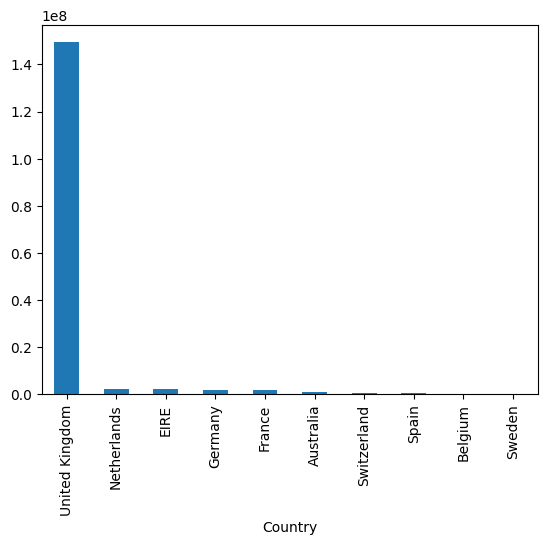

In [ ]:
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

Vizualization anlysis confirmed a strong revenue concentration in the United Kingdom, with significantly lower revenue contributions from other countries

<Axes: xlabel='Country'>

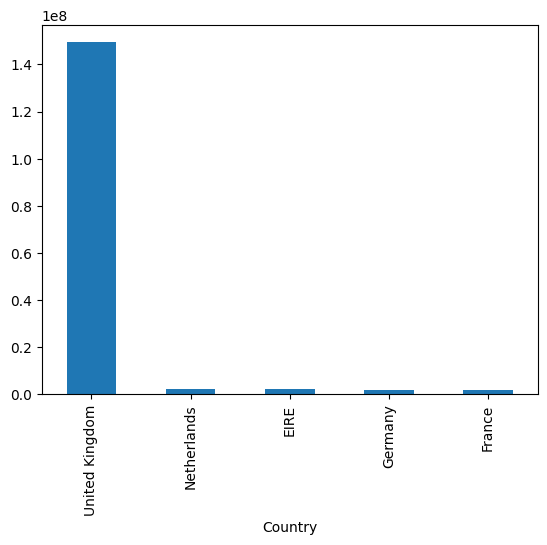

In [ ]:
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5).plot(kind='bar')

#Refund Analysis

<Axes: xlabel='Country'>

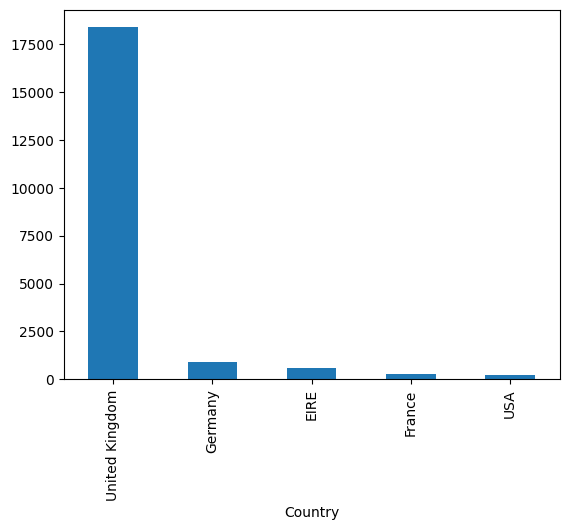

In [ ]:
df[df['NumberOfItemsPurchased']<0].groupby('Country')['TransactionId'].count().sort_values(ascending=False).head(5).plot(kind='bar')

Refund activity is heavily concentrated in the United Kingdom, suggesting a strong dependency on the UK market and higher operational exposure compared to other countries

#Product Revenue Analysis

In [ ]:
df.groupby('ItemDescription')['Revenue'].sum().sort_values(ascending=False).head(10)

,Revenue
ItemDescription,
RETROSPOT LAMP,81447074.13
DOTCOM POSTAGE,1595201.31
REGENCY CAKESTAND 3 TIER,1271536.53
WHITE HANGING HEART T-LIGHT HOLDER,766572.72
PARTY BUNTING,763726.89
JUMBO BAG RED RETROSPOT,711640.44
POSTAGE,547552.41
RABBIT NIGHT LIGHT,511220.67
PAPER CHAIN KIT 50'S CHRISTMAS,504411.30


Revenue is highly concentrated among a few products
Retrospot lamp is a major revenue driver
Shipping/postage items also contribute strongly to revenue
Certain decorative/ home products dominate sales

<Axes: xlabel='ItemDescription'>

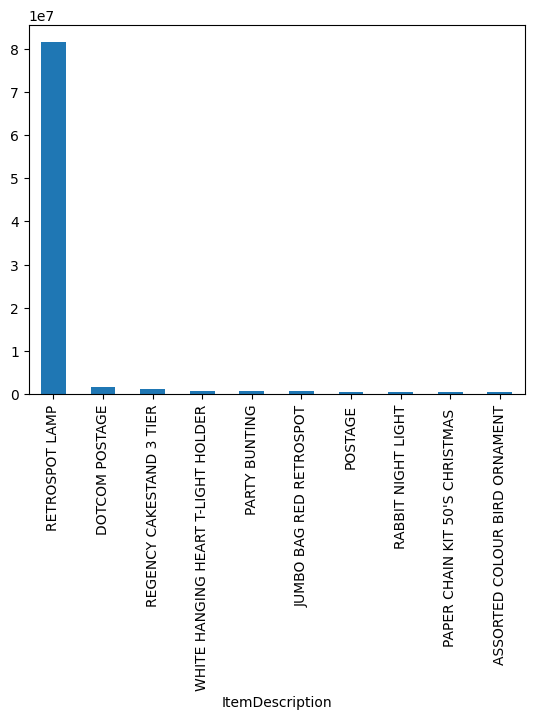

In [ ]:
df.groupby('ItemDescription')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

<Axes: xlabel='ItemDescription'>

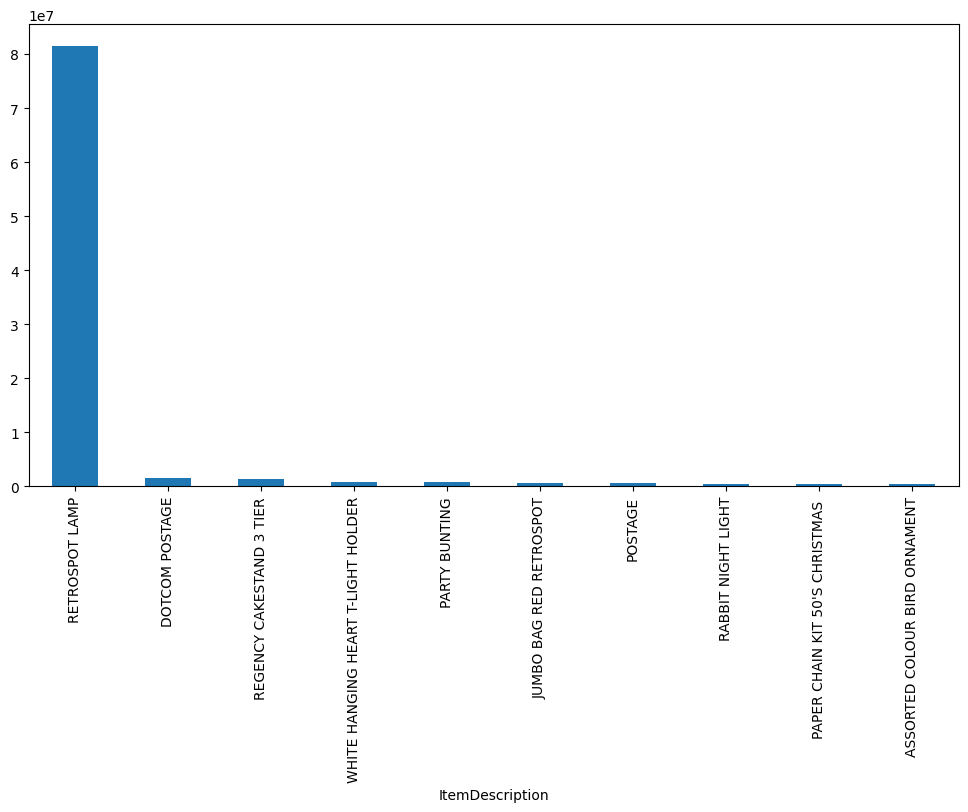

In [ ]:
df.groupby('ItemDescription')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar', figsize= (12,6))

One product dominates revenue massively
The rest contribute far less
Revenue concentration risk exists

In [ ]:
top_product= df.groupby('ItemDescription')['Revenue'].sum().sort_values(ascending=False).head(1)
(top_product.sum()/df['Revenue'].sum())*100

np.float64(52.12308219423824)

Revenue analysis revealed a significant concentration risk, with a single product accounting for approximately 52% of total company revenue.This suggests strong dependency on a single product and may require monitoring from a business risk perspective

#Export Dataset for Power BI

#Export Cleaned dataset

In [ ]:
df.to_csv('cleaned_transactions_powerbi.csv', index=False)

#Create Zip File

In [ ]:
import zipfile
with zipfile.ZipFile('transactions_powerbi.zip','w') as zipf:
  zipf.write('cleaned_transactions_powerbi.csv')

#Smaller sample for Power BI

In [ ]:
sample_df=df.sample(100000)
sample_df.to_csv('powerbi_sample.cvs',index=False)

#Business Insights

The analysis revealed strong revenue concentration in the United Kingdom, indicating significant geographic dependency.
Refund transactions represented a relatively small proportion of total transactions, although monitoring refund behavior remains important for a risk management perspective.
Product analysis showed than a single product contributed more than 50 % of total revenue, highlighting concentration risk and  dependency on a limited number of high-performing items.
Overall, the data set demonstrated strong data quality with minimal missing values, making it suitable for futher business intelligence and dashboard development in Power BI.